<a href="https://colab.research.google.com/github/Aws-Abdullah/NLP-Project/blob/main/phase_2_seq2seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arabic Abstractive Text Summarization - Phase 2
## Seq2Seq with Bahdanau Attention

This notebook builds the model, trains it, and evaluates it using ROUGE metrics.

---
## ⚠️ LOAD PHASE 1 OUTPUTS

This cell loads the saved files from Phase 1. Adjust `DATA_DIR` to wherever you saved them (Google Drive, Kaggle dataset, or Colab session).

Required variables after this cell:
- `X_train`, `X_val`, `X_test` → padded article sequences
- `y_train`, `y_val`, `y_test` → padded summary sequences
- `tokenizer` → fitted Keras Tokenizer
- `test_df` → test DataFrame (needed for ROUGE evaluation on raw text)

---

In [ ]:
!ls /kaggle/input/datasets/hamzehjarrar/nlp-phase2-data/

test_df.pkl    X_test.npy   X_val.npy	y_train.npy
tokenizer.pkl  X_train.npy  y_test.npy	y_val.npy


In [ ]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path

# Minimal path fix: keeps the original Phase 2 model/training code unchanged.
CANDIDATE_DIRS = [
    Path('/content'),
    Path('/content/NLP_400'),
    Path('/content/drive/MyDrive/NLP_400'),
    Path('/kaggle/input/datasets/hamzehjarrar/nlp-phase2-data'),
    Path('.'),
]

REQUIRED_FILES = ['X_train.npy', 'X_val.npy', 'X_test.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'tokenizer.pkl', 'test_df.pkl']
DATA_DIR = next((p for p in CANDIDATE_DIRS if all((p / f).exists() for f in REQUIRED_FILES)), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find Phase 1 output files. Upload the .npy/.pkl files to Colab /content or put them beside this notebook.')

print('Loading Phase 1 files from:', DATA_DIR)
X_train = np.load(DATA_DIR / 'X_train.npy')
X_val   = np.load(DATA_DIR / 'X_val.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_val   = np.load(DATA_DIR / 'y_val.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

test_df = pd.read_pickle(DATA_DIR / 'test_df.pkl')

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('Vocab size:', len(tokenizer.word_index))


X_train: (51138, 400)
y_train: (51138, 50)
Vocab size: 382828


## Imports and setup

In [ ]:
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Concatenate, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print('GPU available:', tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Hyperparameters and data prep

This cell does three things:
1. Gets `sos` / `eos` token IDs from the tokenizer (Phase 1 v2 fits on summaries so these are guaranteed present)
2. Sets hyperparameters — **if on Kaggle P100, consider `USE_SUBSET = False` to train on the full ~49k samples**
3. Splits summaries for training — at each decoder position, the model predicts the next token given the previous ones

In [ ]:
# Get sos/eos token IDs
word_index = tokenizer.word_index
sos_id = word_index['sos']
eos_id = word_index['eos']
print(f'sos_id={sos_id}, eos_id={eos_id}')

# Hyperparameters
VOCAB_SIZE = 30000
EMBEDDING_DIM = 128
LATENT_DIM = 256
BATCH_SIZE = 64
EPOCHS = 20
MAX_ARTICLE_LEN = X_train.shape[1]
MAX_SUMMARY_LEN = y_train.shape[1]

# Subsetting: set USE_SUBSET=False to train on the full dataset (recommended on Kaggle P100)
USE_SUBSET = False
SUBSET_SIZE = 30000
if USE_SUBSET and len(X_train) > SUBSET_SIZE:
    idx = np.random.RandomState(42).choice(len(X_train), SUBSET_SIZE, replace=False)
    X_train_sub = X_train[idx]
    y_train_sub = y_train[idx]
else:
    X_train_sub = X_train
    y_train_sub = y_train

# At each decoder position, we want the model to predict the NEXT token given the previous ones.
# Input = all tokens except the last. Target = all tokens except the first.
dec_in_train = y_train_sub[:, :-1]
dec_out_train = y_train_sub[:, 1:]
dec_in_val = y_val[:, :-1]
dec_out_val = y_val[:, 1:]

print(f'Training on {X_train_sub.shape[0]} samples')
print(f'Article length: {MAX_ARTICLE_LEN}, Summary length: {MAX_SUMMARY_LEN}')

sos_id=17, eos_id=18
Training on 51138 samples
Article length: 400, Summary length: 50


## Bahdanau Attention Layer

At each decoder step, this layer scores every encoder output, turns the scores into weights with softmax, and returns a weighted sum of the encoder outputs (the context vector). The three dense layers `W1`, `W2`, `V` are learned during training.

In [ ]:
class BahdanauAttention(Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, inputs):
        encoder_out, decoder_out = inputs

        enc_exp = tf.expand_dims(encoder_out, 1)
        dec_exp = tf.expand_dims(decoder_out, 2)

        score = self.V(tf.nn.tanh(self.W1(enc_exp) + self.W2(dec_exp)))
        score = tf.squeeze(score, -1)

        attn_weights = tf.nn.softmax(score, axis=-1)
        context = tf.matmul(attn_weights, encoder_out)
        return context, attn_weights

## Build the Seq2Seq model with attention

**Encoder:** Embedding → Bidirectional LSTM → concatenate forward/backward states

**Decoder:** Embedding → LSTM (initialized with encoder states) → Attention → Concat → Dense softmax

In [ ]:
# Encoder
encoder_inputs = Input(shape=(MAX_ARTICLE_LEN,), name='encoder_input')
enc_emb = Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(encoder_inputs)

enc_lstm = Bidirectional(
    LSTM(LATENT_DIM, return_sequences=True, return_state=True, dropout=0.2)
)
enc_out, fwd_h, fwd_c, bwd_h, bwd_c = enc_lstm(enc_emb)

state_h = Concatenate()([fwd_h, bwd_h])
state_c = Concatenate()([fwd_c, bwd_c])
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name='decoder_input')
dec_emb_layer = Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(LATENT_DIM * 2, return_sequences=True, return_state=True, dropout=0.2)
dec_out, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

# Attention + output
attention = BahdanauAttention(LATENT_DIM)
context, attn_weights = attention([enc_out, dec_out])

decoder_concat = Concatenate(axis=-1)([dec_out, context])
decoder_dense = Dense(VOCAB_SIZE, activation='softmax')
decoder_outputs = decoder_dense(decoder_concat)

# Compile
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention_1' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 400, 128)  │  3,840,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 400)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ [(None, 400,      │    788,480 │ embedding_2[0][0… │
│ (Bidirectional)     │ 512), (None,      │            │ not_equal_2[0][0] │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, None, 128) │  3,840,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 512)       │          0 │ bidirectional_1[… │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 512)       │          0 │ bidirectional_1[… │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, None,     │  1,312,768 │ embedding_3[0][0… │
│                     │ 512), (None,      │            │ concatenate_4[0]… │
│                     │ 512), (None,      │            │ concatenate_5[0]… │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention… │ [(None, None,     │    262,913 │ bidirectional_1[… │
│ (BahdanauAttention) │ 512), (None,      │            │ lstm_3[0][0]      │
│                     │ None, 400)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, None,      │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │ 1024)             │            │ bahdanau_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, None,      │ 30,750,000 │ concatenate_6[0]… │
│                     │ 30000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,794,161 (155.62 MB)

 Trainable params: 40,794,161 (155.62 MB)

 Non-trainable params: 0 (0.00 B)

## Train the model

Uses early stopping on validation loss (patience=2) and saves the best checkpoint.

Epoch 1/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 320s 395ms/step - accuracy: 0.3841 - loss: 5.5401 - val_accuracy: 0.4180 - val_loss: 4.5682
Epoch 2/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 315s 394ms/step - accuracy: 0.4249 - loss: 4.3863 - val_accuracy: 0.4482 - val_loss: 4.0279
Epoch 3/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 316s 394ms/step - accuracy: 0.4543 - loss: 3.8269 - val_accuracy: 0.4655 - val_loss: 3.7538
Epoch 4/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 316s 395ms/step - accuracy: 0.4731 - loss: 3.4506 - val_accuracy: 0.4756 - val_loss: 3.6076
Epoch 5/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 315s 394ms/step - accuracy: 0.4919 - loss: 3.1333 - val_accuracy: 0.4811 - val_loss: 3.5397
Epoch 6/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 315s 394ms/step - accuracy: 0.5053 - loss: 2.8894 - val_accuracy: 0.4844 - val_loss: 3.5173
Epoch 7/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 313s 391ms/step - accuracy: 0.5217 - loss: 2.6708 - val_accuracy: 0.4854 - val_loss: 3.5266
Epoch 8/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 313s 391ms/step - accuracy: 0.5393 -

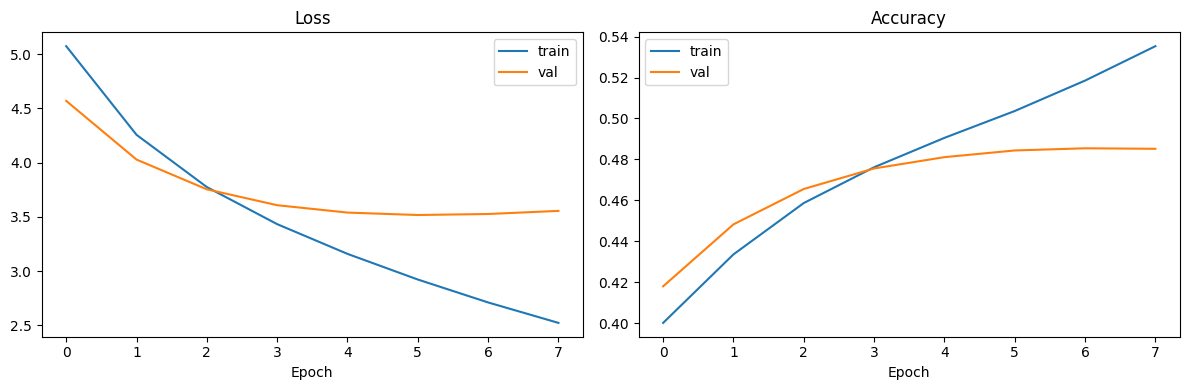

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    [X_train_sub, dec_in_train],
    np.expand_dims(dec_out_train, -1),
    validation_data=([X_val, dec_in_val], np.expand_dims(dec_out_val, -1)),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## Inference models and greedy decoding

For generation we split the trained model into two pieces:
- **Encoder model** — runs once on the article, returns encoder outputs and states
- **Decoder model** — runs token by token, takes the previous token + encoder outputs + previous states

The `generate_summary` function uses these to produce a summary one word at a time until `eos` is generated or `MAX_SUMMARY_LEN` is reached.

In [ ]:
# Encoder inference model
encoder_model = Model(encoder_inputs, [enc_out, state_h, state_c])

# Decoder inference model
dec_state_h_in = Input(shape=(LATENT_DIM * 2,))
dec_state_c_in = Input(shape=(LATENT_DIM * 2,))
dec_enc_out_in = Input(shape=(MAX_ARTICLE_LEN, LATENT_DIM * 2))

dec_emb_inf = dec_emb_layer(decoder_inputs)
dec_out_inf, h_inf, c_inf = decoder_lstm(
    dec_emb_inf, initial_state=[dec_state_h_in, dec_state_c_in]
)
context_inf, _ = attention([dec_enc_out_in, dec_out_inf])
dec_concat_inf = Concatenate(axis=-1)([dec_out_inf, context_inf])
dec_outputs_inf = decoder_dense(dec_concat_inf)

decoder_model = Model(
    [decoder_inputs, dec_enc_out_in, dec_state_h_in, dec_state_c_in],
    [dec_outputs_inf, h_inf, c_inf]
)

# Word lookup
index_to_word = {v: k for k, v in tokenizer.word_index.items()}
index_to_word[0] = ''

# Greedy decoding
# def generate_summary(input_seq):
#     enc_out_val, h, c = encoder_model.predict(input_seq, verbose=0)
#     target = np.array([[sos_id]])
#     decoded = []

#     for _ in range(MAX_SUMMARY_LEN):
#         probs, h, c = decoder_model.predict([target, enc_out_val, h, c], verbose=0)
#         token_id = int(np.argmax(probs[0, -1, :]))

#         if token_id == eos_id or token_id == 0:
#             break

#         word = index_to_word.get(token_id, '')
#         if word and word not in ('sos', 'eos'):
#             decoded.append(word)

#         target = np.array([[token_id]])

#     return ' '.join(decoded)


OOV_id = tokenizer.word_index['<OOV>']
def generate_summary(input_seq):
    enc_out_val, h, c = encoder_model.predict(input_seq, verbose=0)
    target = np.array([[sos_id]])
    decoded = []

    for _ in range(MAX_SUMMARY_LEN):
        probs, h, c = decoder_model.predict([target, enc_out_val, h, c], verbose=0)

        p = probs[0, -1, :].copy()
        p[OOV_id] = 0  # ban OOV
        p[0] = 0       # ban padding

        # Reduce short-loop repetition in generated summaries.
        for used_word in decoded[-5:]:
            used_id = tokenizer.word_index.get(used_word)
            if used_id is not None and used_id < len(p):
                p[used_id] *= 0.3

        token_id = int(np.argmax(p))

        if token_id == eos_id:
            break

        word = index_to_word.get(token_id, '')
        if word and word not in ('sos', 'eos'):
            decoded.append(word)

        target = np.array([[token_id]])

    return ' '.join(decoded)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention_1' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## ROUGE evaluation and qualitative examples

In [ ]:
!pip install rouge-score -q

In [ ]:
from rouge_score import rouge_scorer

# Custom tokenizer for Arabic (default rouge-score tokenizer strips non-ASCII)
class ArabicTokenizer:
    def tokenize(self, text):
        return text.split()

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=False,
    tokenizer=ArabicTokenizer()
)

# Evaluate on a sample from the test set
N_EVAL = 200
eval_idx = np.random.RandomState(0).choice(len(X_test), min(N_EVAL, len(X_test)), replace=False)

scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
generated, references = [], []
test_texts = test_df['summarizer'].values

for i, idx in enumerate(eval_idx):
    pred = generate_summary(X_test[idx:idx+1])
    ref = test_texts[idx].replace('sos', '').replace('eos', '').strip()

    s = scorer.score(ref, pred)
    scores['rouge1'].append(s['rouge1'].fmeasure)
    scores['rouge2'].append(s['rouge2'].fmeasure)
    scores['rougeL'].append(s['rougeL'].fmeasure)

    generated.append(pred)
    references.append(ref)

    if (i + 1) % 50 == 0:
        print(f'{i+1}/{len(eval_idx)} done')

print()
print(f'ROUGE-1: {np.mean(scores["rouge1"]):.4f}')
print(f'ROUGE-2: {np.mean(scores["rouge2"]):.4f}')
print(f'ROUGE-L: {np.mean(scores["rougeL"]):.4f}')

# Qualitative examples
print('\n--- Sample outputs ---')
for i in range(5):
    print(f'\nExample {i+1}')
    print('Reference:', references[i])
    print('Generated:', generated[i])

pd.DataFrame({
    'reference': references,
    'generated': generated
}).to_csv('generated_vs_reference.csv', index=False)

print('Saved generated_vs_reference.csv')


50/50 done

ROUGE-1: 0.1345
ROUGE-2: 0.0162
ROUGE-L: 0.1043

--- Sample outputs ---

Example 1
Reference: ومع تمسك الضحيه بحقيبتها، استعانت النشاله بشفره حلاقه واعتدت عليها علي مستوي الوجه، قبل ان يتدخل اعوان الامن بمساعده عدد من المواطنين لايقافها اقدمت صباح اليوم الاحد، فتاه تبلغ من العمر نحو سنه علي محاوله نشل حقيبه يد احدي المتسوقات في السوق الاسبوعيه بالنفيضه، من ولايه سوسه، امام مراي الجميع
Generated: وقد تم نقل الجثه الي المستشفي الجامعي الطاهر الطاهر صفر في انتظار التعرف علي جثه شاب من مواليد سنه من طرف مواطن علي مستوي وادي من ولايه سوسه وقد تم نقل الجثه الي المستشفي الجامعي الطاهر الطاهر صفر بالمهديه في انتظار التعرف علي جثه شاب من مواليد سنه

Example 2
Reference: ستيف بانون، مستشار ترامب السابق هو راءد اليمين الشعبوي بامريكا والان يريد بانون للانتقال الي بروكسل وانشاء حركه يمينيه شعبويه في اوروبا، كي تمثل ثقلا في مواجهه المستثمر جورج سوروس، الذي يدعم مجموعات ليبراليه
Generated: بعد ان ادلي به الرءيس الامريكي دونالد ترامب في الانتخابات الرءاسيه الامريكيه في الانتخابات الرءاسيه

## Save model, tokenizer and config

These files are what the Streamlit UI (Phase 3) will load for inference. Saved to the current working directory — move them to Drive if you want them to persist.

In [ ]:
model.save('seq2seq_attention.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

config = {
    'vocab_size': VOCAB_SIZE,
    'embedding_dim': EMBEDDING_DIM,
    'latent_dim': LATENT_DIM,
    'max_article_len': MAX_ARTICLE_LEN,
    'max_summary_len': MAX_SUMMARY_LEN,
    'sos_id': sos_id,
    'eos_id': eos_id
}
with open('config.pkl', 'wb') as f:
    pickle.dump(config, f)

print('Saved: seq2seq_attention.keras, tokenizer.pkl, config.pkl')

Saved: seq2seq_attention.keras, tokenizer.pkl, config.pkl


In [ ]:
!ls -lh /kaggle/working/

total 953M
-rw-r--r-- 1 root root 467M Apr 22 11:29 best_model.keras
-rw-r--r-- 1 root root  129 Apr 22 13:07 config.pkl
-rw-r--r-- 1 root root 467M Apr 22 13:07 seq2seq_attention.keras
-rw-r--r-- 1 root root  19M Apr 22 13:07 tokenizer.pkl
-rw-r--r-- 1 root root  57K Apr 22 11:40 training_curves.png


In [ ]:
!rm /kaggle/working/best_model.keras

In [ ]:
!cd /kaggle/working && zip all_outputs.zip seq2seq_attention.keras tokenizer.pkl config.pkl training_curves.png
!ls -lh /kaggle/working/all_outputs.zip

  adding: seq2seq_attention.keras (deflated 7%)
  adding: tokenizer.pkl (deflated 63%)
  adding: config.pkl (deflated 15%)
  adding: training_curves.png (deflated 8%)
-rw-r--r-- 1 root root 440M Apr 22 13:11 /kaggle/working/all_outputs.zip


In [ ]:
!ls -lh /kaggle/working/

total 926M
-rw-r--r-- 1 root root 440M Apr 22 13:11 all_outputs.zip
-rw-r--r-- 1 root root  129 Apr 22 13:07 config.pkl
-rw-r--r-- 1 root root 467M Apr 22 13:07 seq2seq_attention.keras
-rw-r--r-- 1 root root  19M Apr 22 13:07 tokenizer.pkl
-rw-r--r-- 1 root root  57K Apr 22 11:40 training_curves.png
